# Basic signals
Neste Notebook trabalharemos nos **sinais digitais essenciais**:

1. Sinal delta $\delta[n]$
2. Sinal degrau $u[n]$
4. Sinal periódico $A \sin(\omega n + \phi)$
5. Sinal aleatório (estocástico)
6. Sinal exponencial

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def SIGNAL(N=100, signal='delta', params=None):
    n = np.arange(N)
    if signal == 'delta':
        '''
        Delta (impulse)
        '''
        x = np.zeros(N)
        x[0] = 1

    if signal == 'step':
        '''
        Step
        '''
        x = np.ones(N)

    if signal == 'exp':
        '''
        Exponential
          - a: coefficient of exponential
        '''
        a = 0.8
        x = a ** n 

    if signal == 'osc':
        '''
        Oscillation
          - P: Period
          - phi: Phase
        '''
        P = params.get('P', 10) if params else 10
        phi = params.get('phi', 0) if params else 0
        A = params.get('A', 1) if params else 1
        wo = 2 * np.pi / P
        x = A * np.sin(wo * n + phi)  # ← Seno com amplitude, frequência e fase

    if signal == 'random':
        '''
        Random
        '''
        if params == 'uniform':
            '''
            Uniform
            '''
            x = np.random.uniform(0, 1, N)
        else:
            '''
            Gaussian
            '''
            x = np.random.randn(N)  
    return n, x

In [57]:
def SIGNALplot(data, n=None, title='Signal'):
    # Se receber tupla, desempacota
    if isinstance(data, tuple):
        n, x = data
    else:
        x = data
        if n is None:
            n = np.arange(len(x))
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.stem(n, x, linefmt='r-', markerfmt='ro', basefmt='k-')
    ax.set_xlabel('n')
    ax.set_ylabel('x[n]')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    


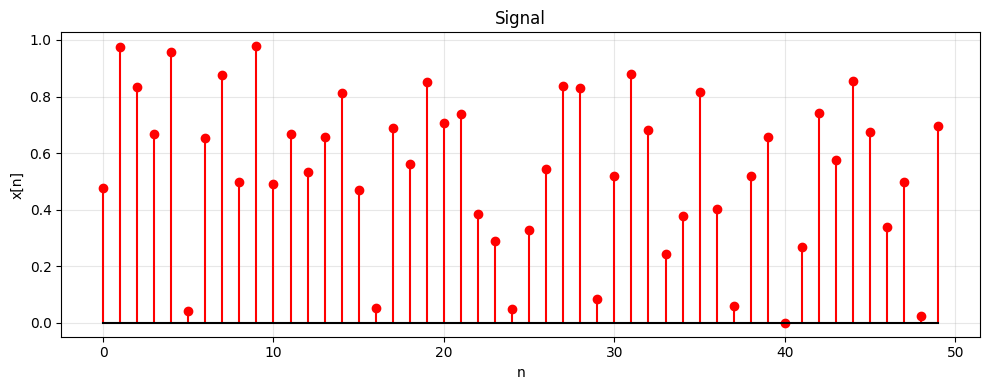

In [60]:
SIGNALplot(SIGNAL(50, 'random','uniform'))

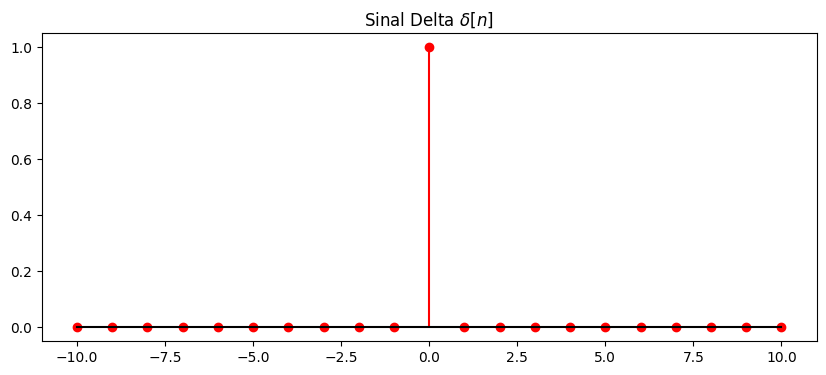

In [10]:
# 1. Sinal delta (v1.0)
'''
Usando vetores
'''
n     = np.arange(-10, 11)
N     = len(n)
xn    = np.zeros(N)
xn[n == 0] = 1

# v2.0
'''
Usando listas
'''
xn    = [1 if sample == 0 else 0 for sample in n]

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(n, xn, linefmt='r-', markerfmt='ro', basefmt='k-')
ax.set_title(r'Sinal Delta $\delta[n]$')
plt.show()

<img src="./figures/delta.png" alt="" width="500"/>

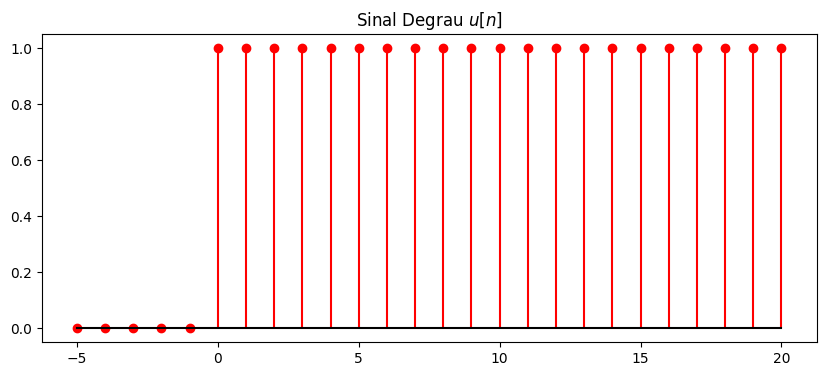

In [11]:
# 2. Degrau (v1.0)
'''
Usando vetores
'''
n      = np.arange(-5, 21)
un     = np.where(n >= 0, 1, 0)

# v2.0
'''
Usando listas
'''
un     = [1 if sample >= 0 else 0 for sample in n]

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(n, un, linefmt='r-', markerfmt='ro', basefmt='k-')
ax.set_title(r'Sinal Degrau $u[n]$')
plt.show()

<img src="./figures/step.png" alt="" width="500"/>

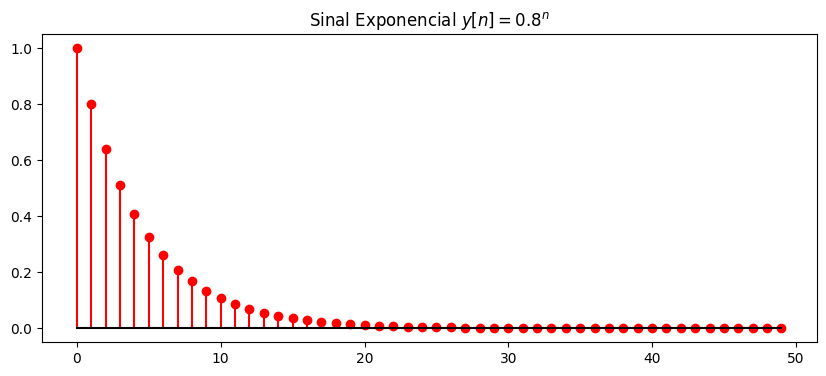

In [13]:
# 3. Exponencial
a  = 0.8
n  = np.arange(0, 50)
yn = a ** n

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(n, yn, linefmt='r-', markerfmt='ro', basefmt='k-')
ax.set_title(f'Sinal Exponencial $y[n] = {a}^n$')
plt.show()

<img src="./figures/exp.png" alt="" width="500"/>

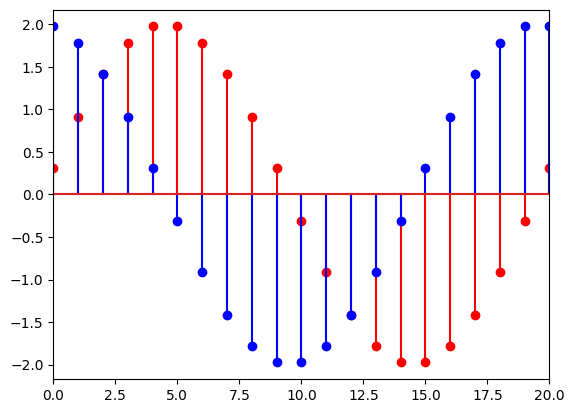

In [27]:
# 4. Sinal periodico
N  = 200
n  = np.arange(N)

A   = 2.0
P   = 20
wo  = 2 * np.pi / P
phi = np.pi / P
xn  = A * np.sin(wo * n + phi)
yn  = A * np.cos(wo * n + phi)

# Plotagem
fig, ax = plt.subplots()
ax.stem(n, xn, 'ro')
ax.stem(n, yn, 'bd')
plt.xlim([0, 20]) 
plt.show()

<img src="./figures/sine.png" alt="" width="500"/>

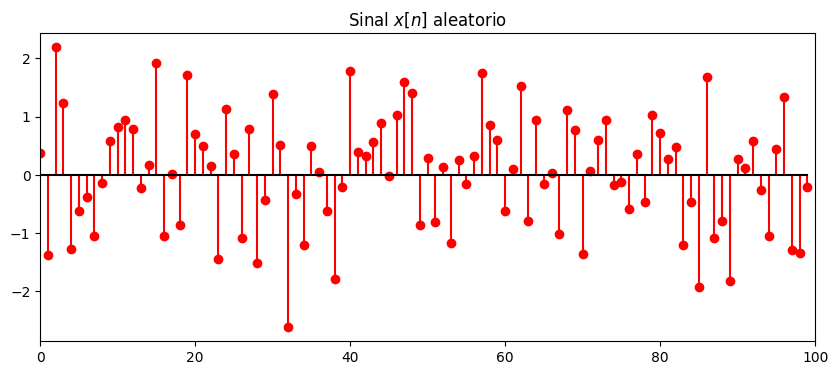

In [28]:
# 5. Sinal aleatorio (distribuicao Gaussiana)
N = 100
n  = np.arange(N)

xn = np.random.randn(N)   

# Plot
fig, ax = plt.subplots(1, figsize=(10, 4))
ax.stem(n, xn, linefmt='ro', markerfmt='ro', basefmt='k-')
plt.xlim([0, 100])
ax.set_title(r'Sinal $x[n]$ aleatorio')
plt.show()

<img src="./figures/random-Gaussian.png" alt="" width="500"/>

Plote o **histograma** deste sinal.

**Dica:** Use `ax.hist`

<!-- help(ax.hist) -->

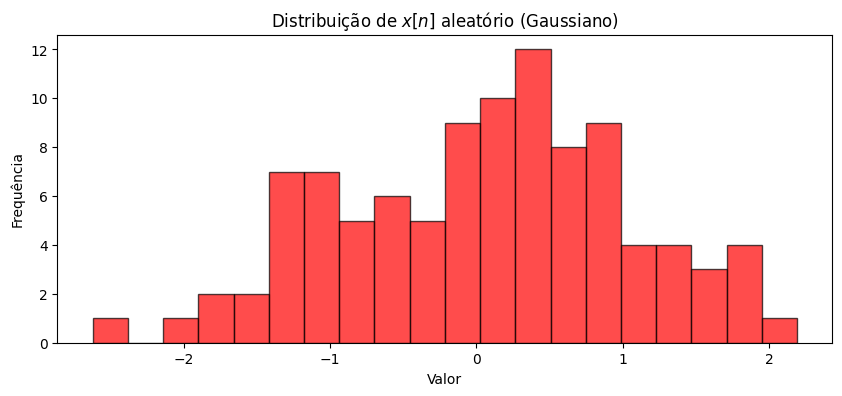

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(xn, bins=20, color='red', alpha=0.7, edgecolor='black')
ax.set_title(r'Distribuição de $x[n]$ aleatório (Gaussiano)')
ax.set_xlabel('Valor')
ax.set_ylabel('Frequência')
plt.show()


<img src="./figures/random-Gaussian-dist.png" alt="" width="500"/>

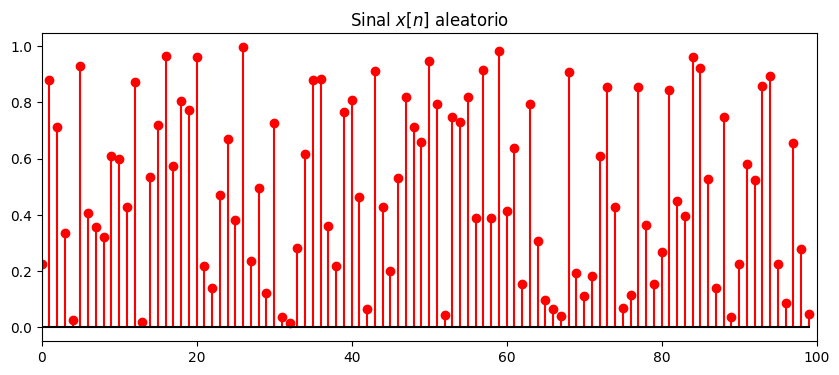

In [31]:
# 5. Sinal aleatorio (distribuicao uniforme)
N = 100
n = np.arange(N)

xn = np.random.uniform(0, 1, N)

# Plot
fig, ax = plt.subplots(1, figsize=(10, 4))
ax.stem(n, xn, linefmt='ro', markerfmt='ro', basefmt='k-')
plt.xlim([0, 100])
ax.set_title(r'Sinal $x[n]$ aleatorio')
plt.show()

<img src="./figures/random-uniform.png" alt="" width="500"/>

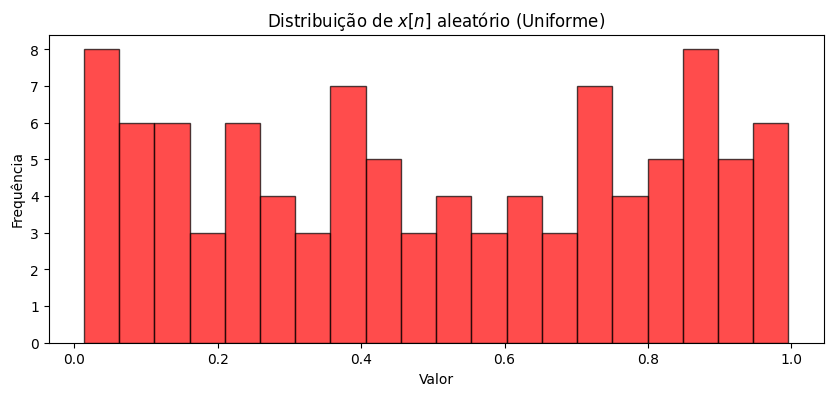

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(xn, bins=20, color='red', alpha=0.7, edgecolor='black')
ax.set_title(r'Distribuição de $x[n]$ aleatório (Uniforme)')
ax.set_xlabel('Valor')
ax.set_ylabel('Frequência')
plt.show()


<img src="./figures/random-uniform-dist.png" alt="" width="500"/>